In [3]:
import wandb

def get_latest_runs_metrics(entity, project, n, metrics):
    print(f"Fetching latest {n} runs from {entity}/{project}...")
    
    api = wandb.Api()
    
    runs = api.runs(f"{entity}/{project}", order="-created_at")
    
    results = []
    count = 0
    for run in runs:
        if count >= n:
            break
        
        run_data = {
            "name": run.name,
            "id": run.id,
            "metrics": {}
        }
        
        # Get summary metrics for each run
        summary = run.summary
        
        for metric in metrics:
            if metric in summary:
                run_data["metrics"][metric] = summary[metric]
            else:
                run_data["metrics"][metric] = None
        
        results.append(run_data)
        count += 1
    
    return results

In [12]:
results = get_latest_runs_metrics(entity = "coactivelearning", 
                                    project = "llama_3_8b_ultrafeedback", 
n = 16, metrics = ["objective/score_total", "objective/scores", "objective/entropy", "objective/kl", "train/penalty_frac", "generation/seq_len_mean", "train/baseline", "train/weighting"])

Fetching latest 16 runs from coactivelearning/llama_3_8b_ultrafeedback...


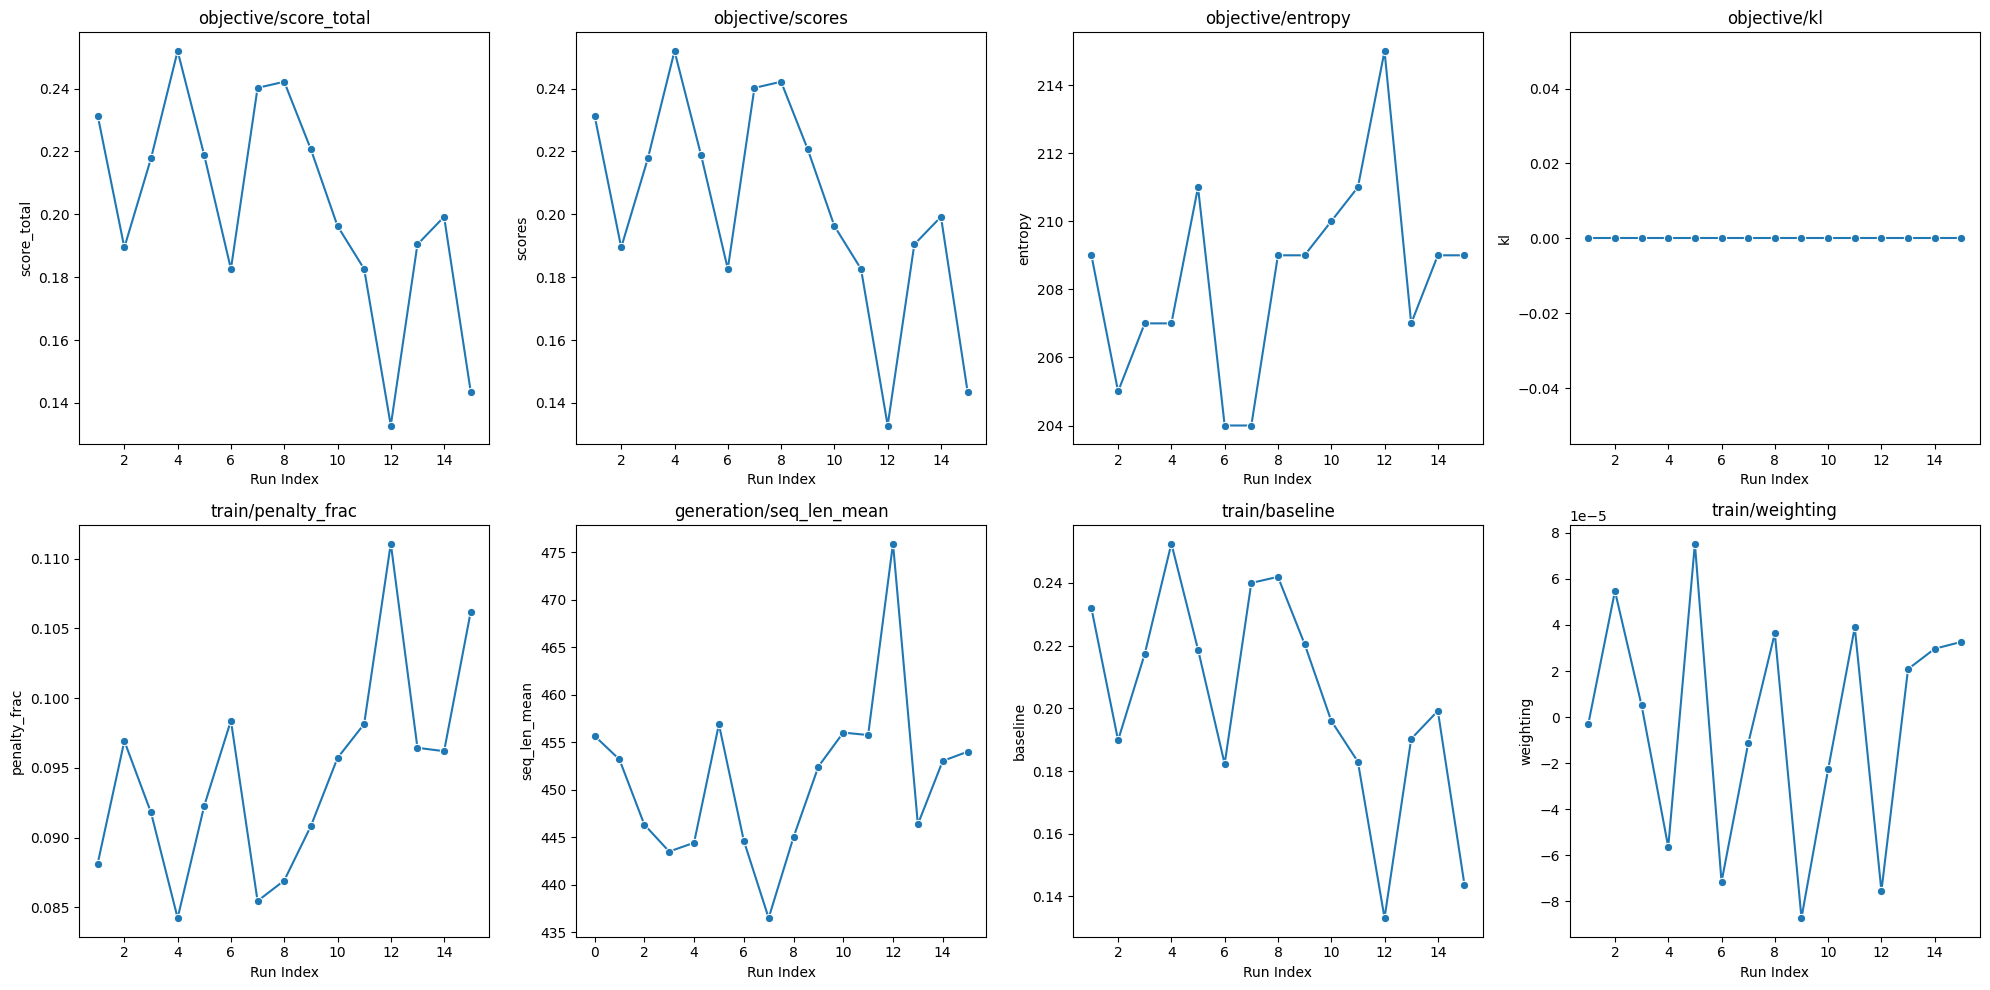

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Convert results to df s.t seaborn can plot it
df_data = []
for i, result in enumerate(results):
    row = {"run_index": i}
    row.update(result["metrics"])
    df_data.append(row)

df = pd.DataFrame(df_data)

metrics = ["objective/score_total", "objective/scores", "objective/entropy", "objective/kl", "train/penalty_frac", "generation/seq_len_mean", "train/baseline", "train/weighting"]
n_metrics = len(metrics)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.lineplot(data=df, x="run_index", y=metric, ax=axes[i], marker='o')
    axes[i].set_title(f'{metric}')
    axes[i].set_xlabel('Run Index')
    axes[i].set_ylabel(metric.split('/')[-1])

plt.tight_layout()
plt.show()